# Bloque 1 — Fundamentos: Transformers, LLMs y Representación Vectorial

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01-fundamentos.ipynb)

> **Carga:** HT: 6h \| HPD: 4h
>
> **Competencias asociadas:**
> [CE-1](../index.qmd#sec-competencias-especificas)
>
> **Dependencias:** `torch`, `transformers`, `sentence-transformers`,
> `chromadb`, `faiss-cpu`, `matplotlib`, `scikit-learn`, `numpy`

> **Orientación previa:** comienza por el [panorama histórico: del texto
> a los embeddings](00-panorama.qmd). Es una introducción conceptual que
> no sustituye los temas técnicos de este bloque.

> **Ejecución en Colab**
>
> Todas las celdas de código están diseñadas para ejecutarse en **Google
> Colab** con GPU T4 gratuita (12 GB RAM).
>
> 1.  Haz clic en el badge “Open in Colab” de arriba
> 2.  Si es la primera vez, autoriza Colab en GitHub: **Settings →
>     GitHub → Connect to GitHub**
> 3.  En Colab: `Runtime → Run all`
>
> Si el badge no funciona, abre
> [colab.research.google.com](https://colab.research.google.com), ve a
> **File → Open Notebook → GitHub**, busca `Adamychen/m10_quarto` y
> selecciona el notebook correspondiente.

## Objetivos del bloque

Comprender la arquitectura que subyace a los LLMs modernos y dominar la
representación vectorial de texto y datos tabulares, así como las bases
de datos vectoriales para búsqueda semántica y recuperación de
información.

## Mapa conceptual del bloque

> **Leyenda de colores**
>
> A lo largo del módulo, los diagramas usan una paleta consistente para
> que identifiques rápidamente el rol de cada elemento. Los azules y el
> amarillo coinciden con la paleta oficial de **Python**.
>
> |  | Significado |
> |------------------------------------|------------------------------------|
> | <span style="display:inline-block;width:1em;height:1em;background:#4B8BBE;border:1px solid #1e3a5f;vertical-align:middle"></span> | **Azul claro** — Input / fuente de datos |
> | <span style="display:inline-block;width:1em;height:1em;background:#306998;border:1px solid #1e3a5f;vertical-align:middle"></span> | **Azul oscuro** — Proceso / orquestación |
> | <span style="display:inline-block;width:1em;height:1em;background:#FFD43B;border:1px solid #b8860b;vertical-align:middle"></span> | **Amarillo** — Resultado intermedio |
> | <span style="display:inline-block;width:1em;height:1em;background:#e65100;border:1px solid #bf360c;vertical-align:middle"></span> | **Naranja** — Aviso / herramienta |
> | <span style="display:inline-block;width:1em;height:1em;background:#2e7d32;border:1px solid #0d3010;vertical-align:middle"></span> | **Verde** — Éxito / meta final |
> | <span style="display:inline-block;width:1em;height:1em;background:#c62828;border:1px solid #7f0000;vertical-align:middle"></span> | **Rojo** — Riesgo / error |

<figure id="fig-mapa-fundamentos">
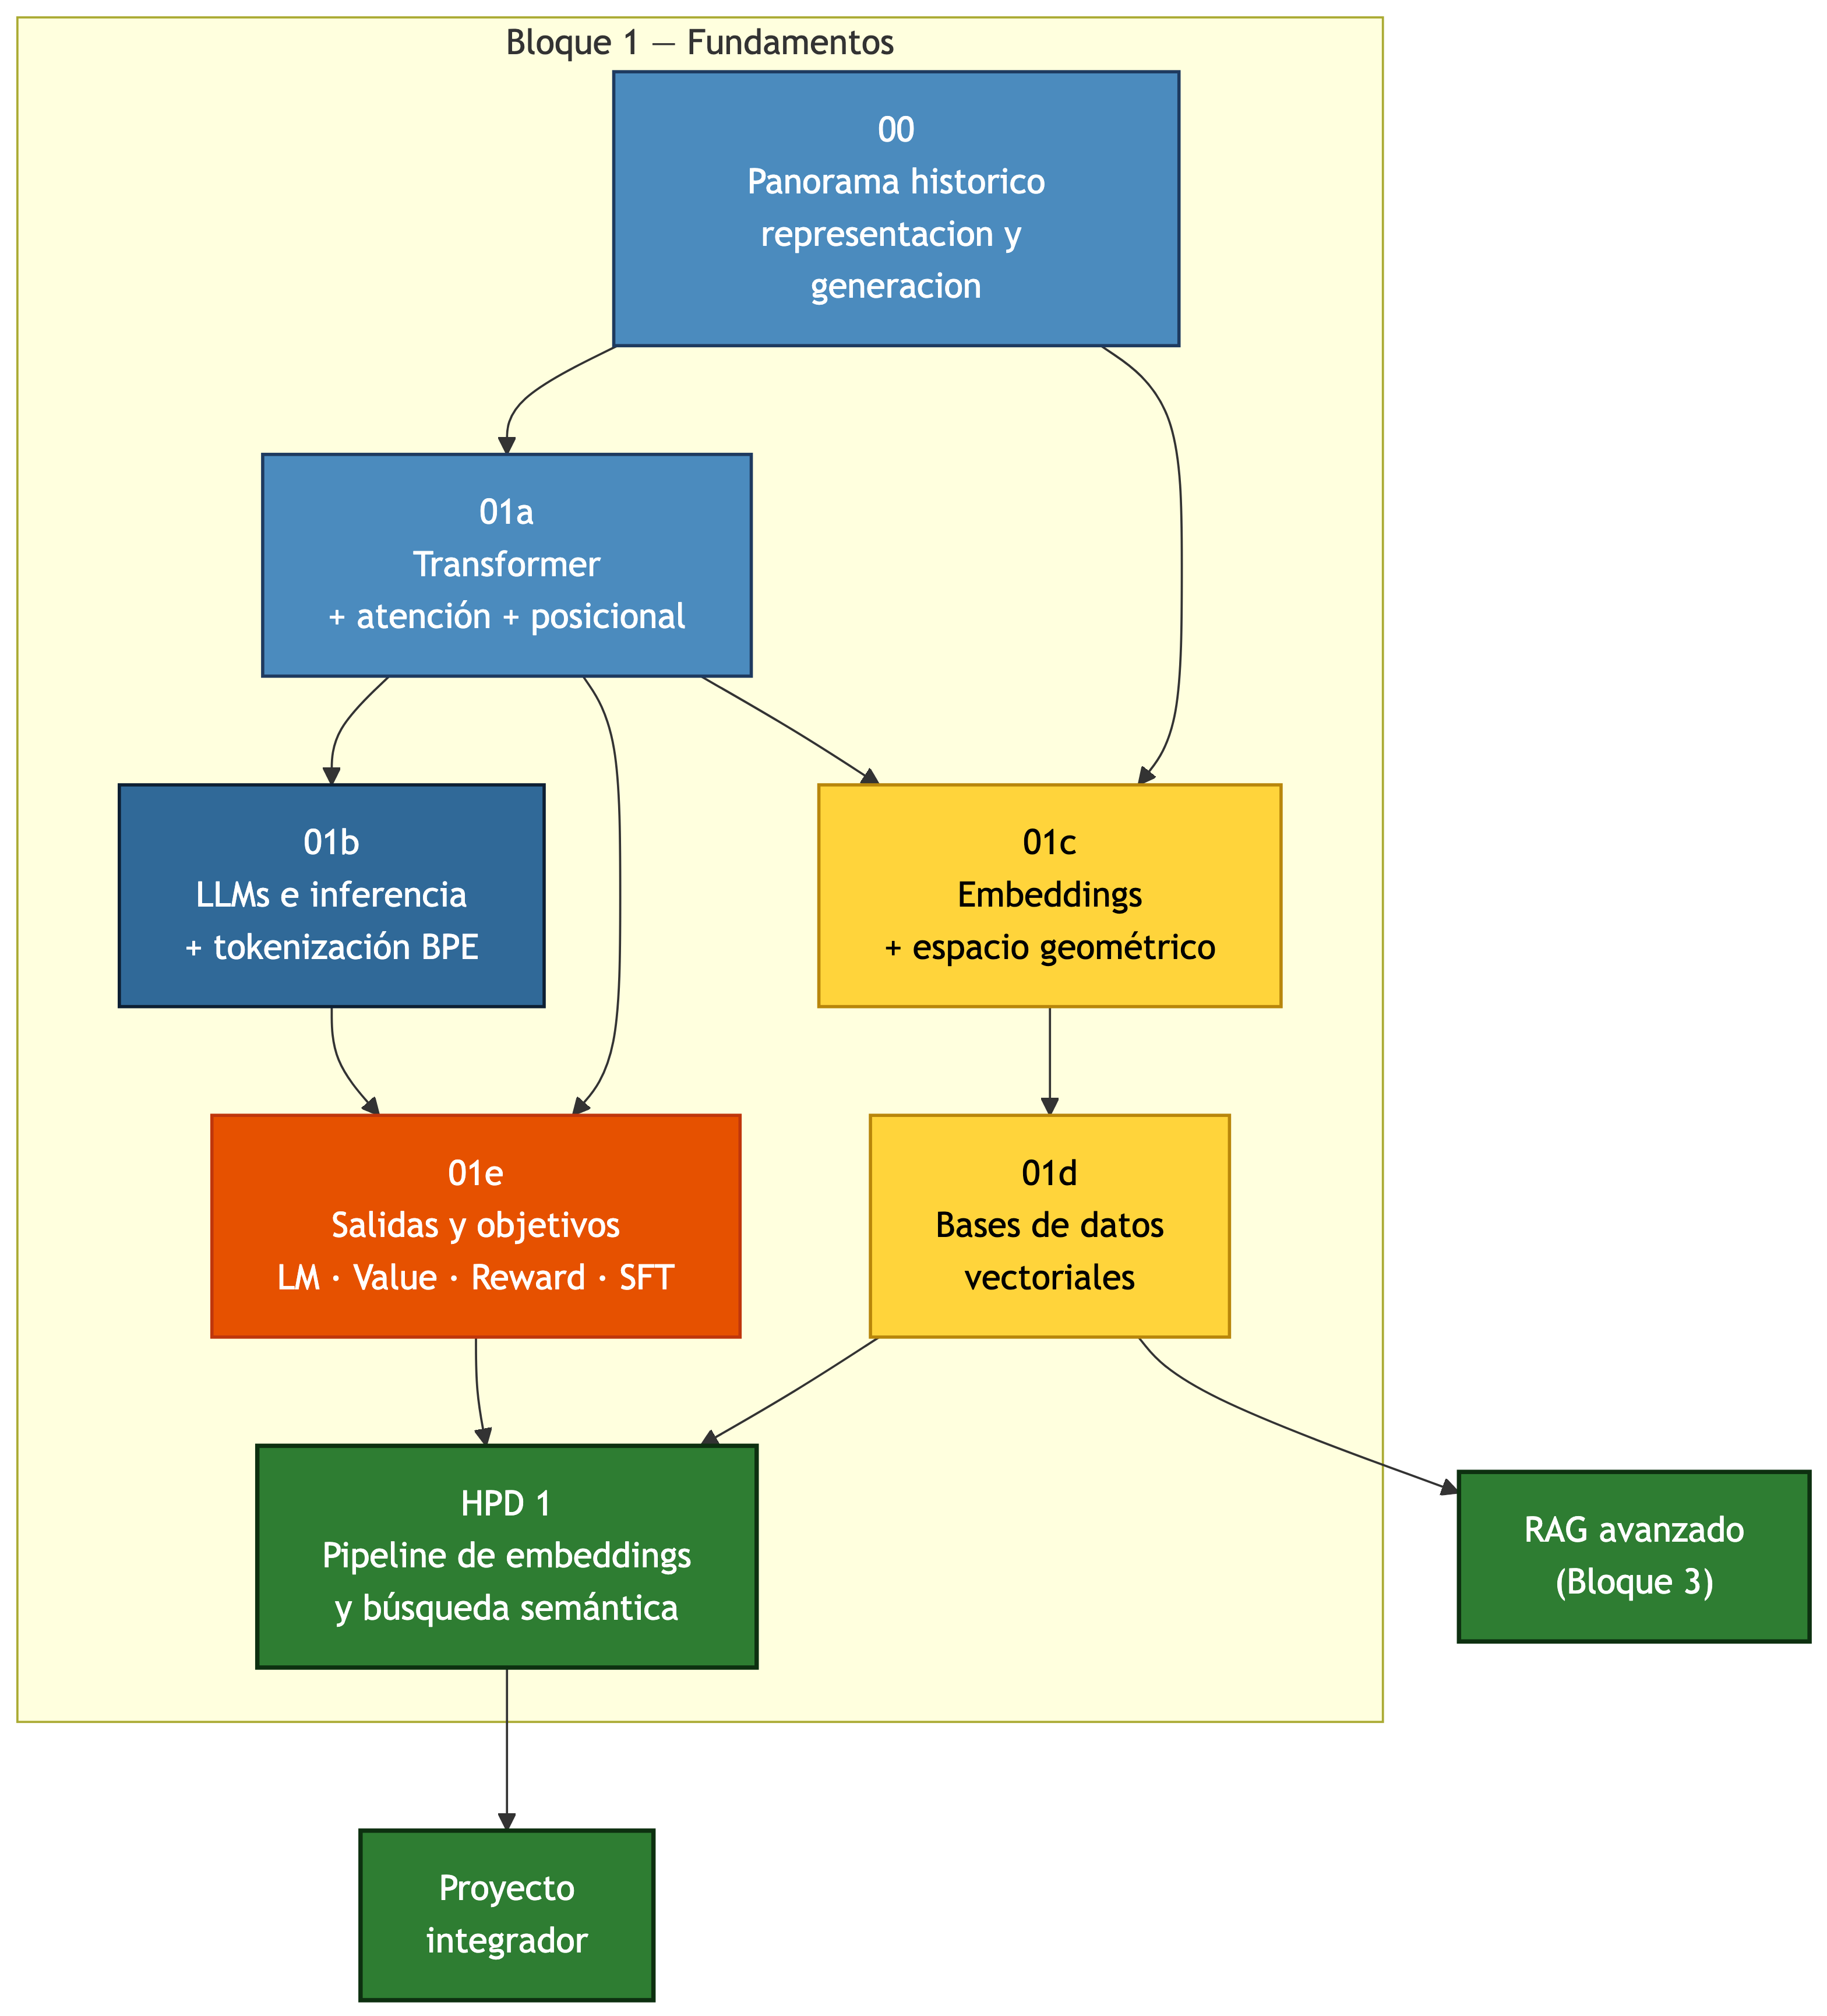
<figcaption>Figure 1</figcaption>
</figure>

Los cuatro pilares de este bloque (Transformer → LLM → Embeddings →
Vector DB) actúan como soporte sobre el que se construye todo el módulo.
El orden sigue una progresión natural basada en dependencias: comenzamos
con la arquitectura Transformer (atención, codificación posicional,
variantes), pasamos a los LLMs y la inferencia (incluyendo una
profundización en tokenización BPE), continuamos con la representación
vectorial del lenguaje (embeddings y su geometría) y terminamos con las
bases de datos vectoriales que permiten búsqueda semántica eficiente. La
página **01e** complementa este recorrido mostrando cómo un mismo
backbone puede producir distintas salidas y cómo SFT, PPO y DPO
modifican el entrenamiento según la tarea.

El [panorama histórico](00-panorama.qmd) añade una perspectiva distinta
a esta secuencia técnica. Allí se sigue la línea **one-hot → TF-IDF →
word2vec/GloVe → representaciones contextuales → SBERT/E5 → RAG**,
mientras que las páginas técnicas explican en detalle la línea
**RNN/LSTM → Transformer → LLM → herramientas y agentes**. Mantener
ambas líneas evita presentar los embeddings como una consecuencia
exclusiva de los LLMs: los embeddings de palabras son anteriores al
Transformer, pero los embeddings contextuales y de frases modernos
aprovechan esta arquitectura.

## Contenido del bloque

La siguiente tabla muestra el itinerario que sigue este bloque en su
exposición de objetivos, así como los ficheros interactivos asociados y
el tiempo estimado necesario para la exposición de los mismos:

| Tema | Archivo | Duración estimada |
|------------------------|------------------------|------------------------|
| **Panorama histórico** — De one-hot y TF-IDF a embeddings contextuales, búsqueda semántica y RAG | [00-panorama.qmd](00-panorama.qmd) | 45-60 min, orientación previa |
| **Transformers** — Pipeline intuitiva, atención, codificación posicional, variantes | [01a-transformer.qmd](01a-transformer.qmd) | 2h |
| **LLMs e inferencia** — Preentrenamiento, BPE paso a paso, parámetros, HF Hub, API Llamus | [01b-llms.qmd](01b-llms.qmd) | 2h |
| **Embeddings** — word2vec, SBERT, espacio geométrico, anisotropía y whitening | [01c-embeddings.qmd](01c-embeddings.qmd) | 1h |
| **Bases de datos vectoriales** — Chroma, FAISS, HNSW, búsqueda semántica | [01d-vectordb.qmd](01d-vectordb.qmd) | 1h |
| **Salidas y objetivos de entrenamiento** — LM, value, reward, SFT, PPO y DPO (lectura recomendada) | [01e-llm-por-dentro.qmd](01e-llm-por-dentro.qmd) | — |
| **HPD 1 — Pipeline de embeddings** | [hpd1-embeddings.qmd](hpd1-embeddings.qmd) | 4h |

Table 1: Itinerario del Bloque 1 con sus ficheros y duración estimada

> **Note**
>
> **Teoría obligatoria.** Los temas 01a-01d son obligatorios. La página
> **01e** es **lectura recomendada** (no obligatoria) y entra en
> evaluación conceptual integrada en el proyecto final, no en un examen
> separado.

In [1]:
!pip install -q chromadb faiss-cpu sentence-transformers


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
import math
print("Librerías cargadas correctamente.")
print(f"NumPy: {np.__version__}")


------------------------------------------------------------------------

## Referencias del bloque

- Vaswani et al. (2017)
- Devlin et al. (2019)
- Kaplan et al. (2020)
- <span class="nocase">Hoffmann et al.</span> (2022)
- Su et al. (2021)
- Dao et al. (2022)
- Reimers & Gurevych (2019)
- Wang et al. (2022)
- Radford et al. (2021)
- Malkov & Yashunin (2020)
- Johnson et al. (2021)
- Sennrich et al. (2016)
- Roitman (2026)

------------------------------------------------------------------------

## Resumen del bloque

<figure id="fig-resumen-bloque-1">
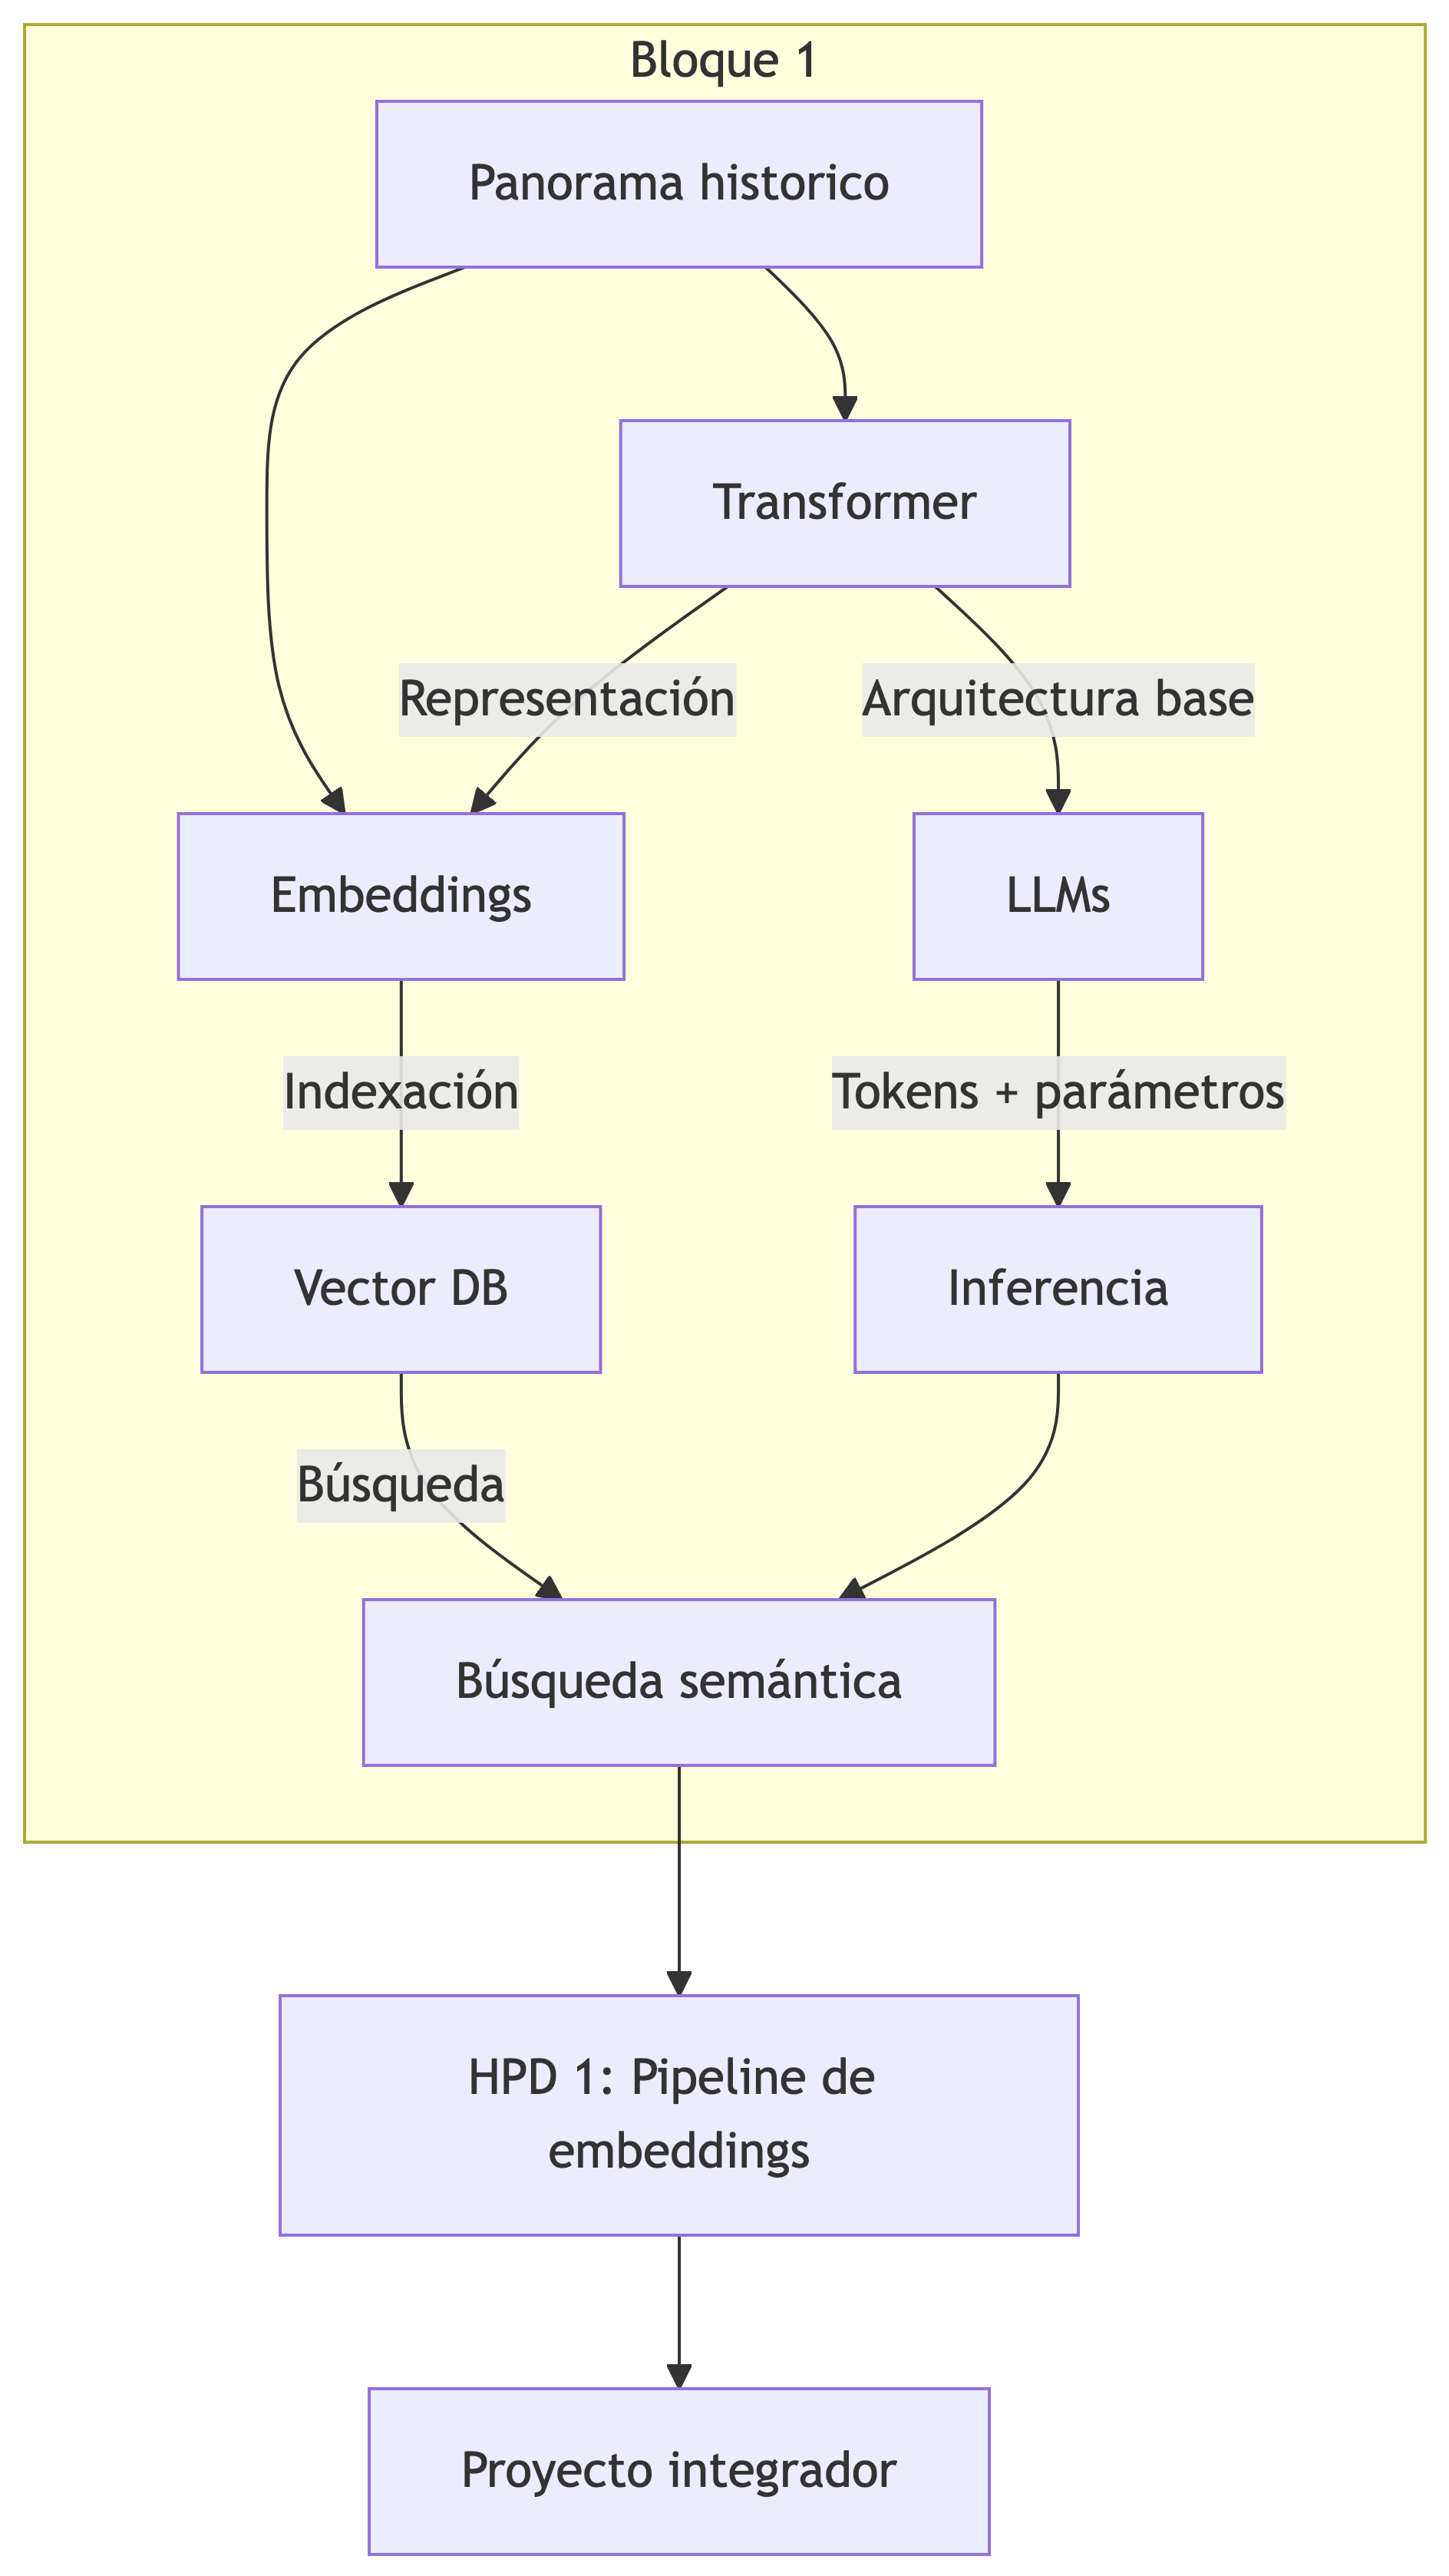
<figcaption>Figure 2</figcaption>
</figure>

Este primer bloque sienta las bases para el resto de bloques que
componen el curso. Concretamente:

- **Bloque 2:** uso de LLMs para construir agentes y prompts
  estructurados
- **Bloque 3:** uso de embeddings + vector DB para construir sistemas
  RAG (recuperación de información)
- **Bloque 4:** evaluación y despliegue de sistemas en producción

Tras haber asimilado los conceptos de las secciones anteriores, puedes
pasar al [taller práctico: HPD 1 — Pipeline de embeddings y búsqueda
semántica](hpd1-embeddings.qmd).

> **Antes de continuar**
>
> 1.  Asegúrate de haber ejecutado `source .venv/bin/activate` (o
>     `setup.bat` en Windows)
> 2.  Confirma que ejecutaste todas las celdas de código de los
>     sub-temas sin errores
> 3.  Lee Vaswani et al. (2017) secciones 3-5 (lectura obligatoria)

------------------------------------------------------------------------

# References

Dao, T., Fu, D. Y., Ermon, S., Rudra, A., & Ré, C. (2022).
FlashAttention: Fast and memory-efficient exact attention with
IO-awareness. *Advances in Neural Information Processing Systems*.
<https://arxiv.org/abs/2205.14135>

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT:
Pre-training of deep bidirectional transformers for language
understanding. *Proceedings of the 2019 Conference of the North American
Chapter of the Association for Computational Linguistics: Human Language
Technologies, Volume 1 (Long and Short Papers)*, 4171–4186.
<https://doi.org/10.18653/v1/N19-1423>

<span class="nocase">Hoffmann, J., Borgeaud, S., Mensch, A.,
Buchatskaya, E., Cai, T., Rutherford, E., de las Casas, D., Hendricks,
L. A., Welbl, J., Clark, A., Lehman, E., Sifre, L., Graves, M.,
Simonyan, K., Penedo, G., Lin, Z., Gokay, D., Mellor, J., Helly, J., …
Brown, T. B.</span> (2022). Training compute-optimal large language
models. *arXiv Preprint arXiv:2203.15556*.
<https://arxiv.org/abs/2203.15556>

Johnson, J., Douze, M., & Jégou, H. (2021). Billion-scale similarity
search with GPUs. *IEEE Transactions on Big Data*, *7*(3), 535–547.
<https://doi.org/10.1109/TBDATA.2019.2921572>

Kaplan, J., McCandlish, S., Henighan, T., Brown, T. B., Chess, B.,
Child, R., Gray, S., Radford, A., Wu, J., & Amodei, D. (2020). Scaling
laws for neural language models. *arXiv Preprint arXiv:2001.08361*.
<https://arxiv.org/abs/2001.08361>

Malkov, Y. A., & Yashunin, D. A. (2020). Efficient and robust
approximate nearest neighbor search using hierarchical navigable small
world graphs. *IEEE Transactions on Pattern Analysis and Machine
Intelligence*, *42*(4), 824–836.
<https://doi.org/10.1109/TPAMI.2018.2889473>

Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S.,
Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G., &
Sutskever, I. (2021). Learning transferable visual models from natural
language supervision (CLIP). *arXiv Preprint arXiv:2103.00020*.
<https://arxiv.org/abs/2103.00020>

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings
using siamese BERT-networks. *Proceedings of the 2019 Conference on
Empirical Methods in Natural Language Processing and the 9th
International Joint Conference on Natural Language Processing
(EMNLP-IJCNLP)*, 3982–3992. <https://doi.org/10.18653/v1/D19-1410>

Roitman, H. (2026). *The hitchhiker’s guide to agentic AI: From
foundations to systems*. Versión 1.2.2. Licencia CC BY-SA 4.0.
<https://creativecommons.org/licenses/by-sa/4.0/>

Sennrich, R., Haddow, B., & Birch, A. (2016). *Neural machine
translation of rare words with subword units*. 1715–1725.
<https://doi.org/10.18653/v1/P16-1162>

Su, J., Lu, Y., Pan, S., Wen, B., & Liu, Y. (2021). RoFormer: Enhanced
transformer with rotary position embedding. *arXiv Preprint
arXiv:2104.09864*. <https://arxiv.org/abs/2104.09864>

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez,
A. N., Kaiser, L., & Polosukhin, I. (2017). *Attention is all you need*.
*30*. <https://arxiv.org/abs/1706.03762>

Wang, L., Yang, N., Huang, X., Jiao, B., Yang, L., Jiang, D., Majumder,
R., & Wei, F. (2022). Text embeddings by weakly-supervised contrastive
pre-training (E5). *arXiv Preprint arXiv:2212.03533*.
<https://arxiv.org/abs/2212.03533>